<h2 style = "color:red"> 1-Data Loading & Exploration </h2>

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

col_names = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin','name']
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data' ,names=col_names,sep=r'\s+',na_values='?')

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB
None


In [3]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year      origin  
count    398.000000  398.000000  398.000000  
mean      15.568090   76.010050    1.572864  
std        2.757689    3.697627    0.802055  
min        8.000000   70.000000    1.000000  
25%       13.825000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%       17.175000   79.0000

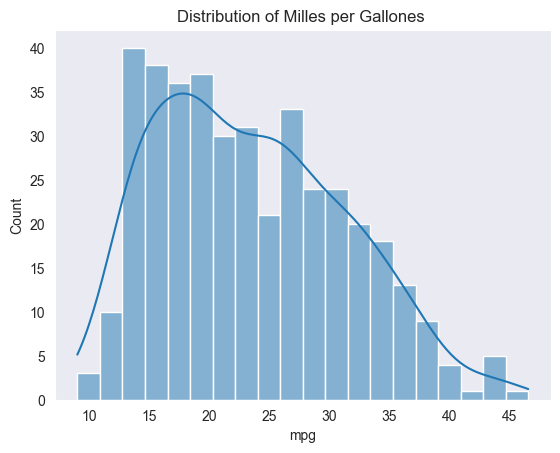

In [13]:
sns.set_style("dark")
sns.histplot(data=df,x=df['mpg'],bins=20,kde=True)
plt.title("Distribution of Milles per Gallones ")
plt.show()

<table style="width: 100%; max-width: 800px; border-left: 6px solid #f0ad4e; background-color: #fcf8e3; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                The distribution of the target variable (<code>mpg</code>) is <b>positively skewed (right-skewed)</b>.
            </p>
            <ul style="color: #555; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 8px;"><b>Observation:</b> Most vehicles are concentrated around lower to moderate fuel efficiency (15–25 MPG), creating a high peak on the left.</li>
                <li style="margin-bottom: 8px;"><b>Tail:</b> A small number of high-efficiency cars stretch the distribution with a long tail toward the right (up to 45+ MPG).</li>
                <li><b>ML Impact:</b> Standard Linear Regression models assume a normal symmetric distribution, so this asymmetry indicates that polynomial features might be needed to capture the data's complexity.</li>
            </ul>
        </td>
    </tr>
</table>

<table style="width: 100%; max-width: 800px; border-left: 6px solid #f0ad4e; background-color: #fcf8e3; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                Potential <b>outliers</b> are visible on the far right end of the histogram.
            </p>
            <ul style="color: #555; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 8px;"><b>Observation:</b> The isolated data points beyond 40 MPG represent exceptionally fuel-efficient vehicles that stand out from the rest of the dataset.</li>
                <li><b>ML Impact:</b> These extreme points can pull the linear regression line toward them, which might affect the baseline model's overall accuracy.</li>
            </ul>
        </td>
    </tr>
</table>

<h2 style = "color:red"> 2-Linear Baseline </h2>


<h2 style = "color:green"> Training & Test </h2>

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge , Lasso
from sklearn.model_selection import GridSearchCV

In [6]:
df_clean = df.dropna()
y = df_clean["mpg"].values
X = df_clean.drop(columns=["mpg","name"]).values
X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train , y_train)
y_predict = model.predict(X_test)

<h2 style = "color:green"> Metrics Computation </h2>

In [8]:
MAE = mean_absolute_error( y_test , y_predict)
MAPE = mean_absolute_percentage_error(y_test , y_predict)
MSE = mean_squared_error(y_test , y_predict)
RMSE = root_mean_squared_error(y_test , y_predict)
R = r2_score(y_test , y_predict)

print(f" MAE = {MAE : .4f} ")
print(f" MAPE = {MAPE : .4f} ")
print(f" MSE = {MSE : .4f} ")
print(f" RMSE = {RMSE : .4f} ")
print(f" R² = {R : .4f} ")

 MAE =  2.4198 
 MAPE =  0.1179 
 MSE =  10.7109 
 RMSE =  3.2727 
 R² =  0.7902 


<table style="width: 100%; max-width: 800px; border-left: 6px solid #f0ad4e; background-color: #fcf8e3; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                The baseline <b>Linear Regression</b> model has been trained and evaluated on the test set. Here are the key performance insights:
            </p>
            <ul style="color: #555; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 8px;"><b>R² Score (0.7902):</b> The model can explain approximately 79% of the variance in fuel efficiency (<code>mpg</code>), indicating a strong initial linear relationship.</li>
                <li style="margin-bottom: 8px;"><b>Average Error (MAE & RMSE):</b> On average, the model's predictions deviate by <b>2.42 MPG</b> (MAE). The higher RMSE (<b>3.27 MPG</b>) penalizes larger errors, confirming the impact of the outliers observed in step 1.</li>
                <li><b>Percentage Error (MAPE):</b> The model has an average error rate of only <b>11.79%</b>.</li>
            </ul>
        </td>
    </tr>
</table>

<h2 style = "color:red"> 3- Polynomial Feature </h2>

In [ ]:
degree = [2,3,4,5]
print(f"{'Degree':<8} | {'MAE':<8} | {'MAPE':<8} | {'MSE':<8} | {'RMSE':<8} | {'R² Score':<8}")
print("-" * 65)

for d in degree:
    poly = PolynomialFeatures( degree=d , include_bias= False )
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly,y_train)
    poly_predict = poly_model.predict(X_test_poly)

    MAE_d = mean_absolute_error( y_test , poly_predict)
    MAPE_d = mean_absolute_percentage_error(y_test , poly_predict)
    MSE_d = mean_squared_error(y_test , poly_predict)
    RMSE_d = root_mean_squared_error(y_test , poly_predict)
    R_d = r2_score(y_test , poly_predict)
    
    print(f"{d:<8} | {MAE_d:<8.4f} | {MAPE_d:<8.4f} | {MSE_d:<8.4f} | {RMSE_d:<8.4f} | {R_d:<8.4f}")

    

Degree   | MAE      | MAPE     | MSE      | RMSE     | R² Score
-----------------------------------------------------------------
2        | 1.9719   | 0.0893   | 7.1568   | 2.6752   | 0.8598  
3        | 3.2477   | 0.1588   | 18.6787  | 4.3219   | 0.6340  
4        | 5.3457   | 0.2734   | 70.3212  | 8.3858   | -0.3778 
5        | 5.6412   | 0.3164   | 100.0036 | 10.0002  | -0.9593 


<table style="width: 100%; max-width: 800px; border-left: 6px solid #d9534f; background-color: #f2dede; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                Testing higher polynomial degrees (from 2 to 5) clearly demonstrates the classic <b>Overfitting</b> phenomenon:
            </p>
            <ul style="color: #555; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 8px;"><b>Degree 2 (Optimal):</b> Provides the best balance with the highest R² (<b>0.8598</b>) and lowest errors.</li>
                <li style="margin-bottom: 8px;"><b>Degrees 4 & 5 (Catastrophic Overfitting):</b> R² drops into <b>negative values</b> (-0.3778 and -0.9593). This indicates that the model became overly complex, memorizing the training data noise, and completely failed to generalize to the unseen test data.</li>
                <li><b>Conclusion:</b> Increasing model complexity beyond Degree 2 destroys generalization.</li>
            </ul>
        </td>
    </tr>
</table>

<h2 style = "color:red"> 4-Regularization (Ridge & Lasso) </h2>

<div style="background-color: #f7fafc; padding: 16px; border-left: 5px solid #1a365d; margin-bottom: 15px; font-family: sans-serif; border-radius: 4px;">
    <h4 style="color: #1a365d; margin: 0 0 10px 0; font-size: 16px;">1. Penalty Type</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.5; margin: 0;">
        <b>Ridge Regularization (L2):</b> Adds squared magnitude of coefficients.<br>
        <span style="display: block; margin-top: 5px;"><b>Lasso Regularization (L1):</b> Adds absolute magnitude of coefficients.</span>
    </p>
</div>

<div style="background-color: #f7fafc; padding: 16px; border-left: 5px solid #2b6cb0; margin-bottom: 15px; font-family: sans-serif; border-radius: 4px;">
    <h4 style="color: #2b6cb0; margin: 0 0 10px 0; font-size: 16px;">2. Coefficient Values</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.5; margin: 0;">
        <b>Ridge Regularization (L2):</b> Shrinks coefficients close to zero, but never exactly zero.<br>
        <span style="display: block; margin-top: 5px;"><b>Lasso Regularization (L1):</b> Can shrink coefficients to exactly zero.</span>
    </p>
</div>

<div style="background-color: #f7fafc; padding: 16px; border-left: 5px solid #2c5282; margin-bottom: 15px; font-family: sans-serif; border-radius: 4px;">
    <h4 style="color: #2c5282; margin: 0 0 10px 0; font-size: 16px;">3. Feature Selection</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.5; margin: 0;">
        <b>Ridge Regularization (L2):</b> No. Keeps all features in the model.<br>
        <span style="display: block; margin-top: 5px;"><b>Lasso Regularization (L1):</b> Yes. Removes useless or redundant features.</span>
    </p>
</div>

<div style="background-color: #f7fafc; padding: 16px; border-left: 5px solid #4299e1; margin-bottom: 15px; font-family: sans-serif; border-radius: 4px;">
    <h4 style="color: #4299e1; margin: 0 0 10px 0; font-size: 16px;">4. Best Used When</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.5; margin: 0;">
        <b>Ridge Regularization (L2):</b> Most features are useful and highly correlated (Multicollinearity).<br>
        <span style="display: block; margin-top: 5px;"><b>Lasso Regularization (L1):</b> You have many features, but only a few of them are actually important.</span>
    </p>
</div>

<div style="background-color: #f7fafc; padding: 16px; border-left: 5px solid #3182ce; margin-bottom: 15px; font-family: sans-serif; border-radius: 4px;">
    <h4 style="color: #3182ce; margin: 0 0 10px 0; font-size: 16px;">5. Resulting Model</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.5; margin: 0;">
        <b>Ridge Regularization (L2):</b> Produces a robust model but still contains all terms.<br>
        <span style="display: block; margin-top: 5px;"><b>Lasso Regularization (L1):</b> Produces a simple, sparse, and easy-to-interpret model.</span>
    </p>
</div>

In [11]:
import warnings
warnings.filterwarnings('ignore')
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train2 = poly2.fit_transform(X_train)
X_test2 = poly2.transform(X_test)

param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_train2, y_train)
best_ridge_model = ridge_grid.best_estimator_
ridge_predict = best_ridge_model.predict(X_test2)

lasso_grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='r2')
lasso_grid.fit(X_train2, y_train)
best_lasso_model = lasso_grid.best_estimator_
lasso_predict = best_lasso_model.predict(X_test2)

ridge_MAE = mean_absolute_error(y_test, ridge_predict)
ridge_MAPE = mean_absolute_percentage_error(y_test, ridge_predict)
ridge_MSE = mean_squared_error(y_test, ridge_predict)
ridge_RMSE = root_mean_squared_error(y_test, ridge_predict)
ridge_R2 = r2_score(y_test, ridge_predict)

lasso_MAE = mean_absolute_error(y_test, lasso_predict)
lasso_MAPE = mean_absolute_percentage_error(y_test, lasso_predict)
lasso_MSE = mean_squared_error(y_test, lasso_predict)
lasso_RMSE = root_mean_squared_error(y_test, lasso_predict)
lasso_R2 = r2_score(y_test, lasso_predict)

print(f"Best Ridge Alpha = {ridge_grid.best_params_['alpha']}")
print(f"Best Lasso Alpha = {lasso_grid.best_params_['alpha']}\n")

print(f"{'Model':<20} | {'MAE':<8} | {'MAPE':<8} | {'MSE':<8} | {'RMSE':<8} | {'R² Score':<8}")
print("-" * 75)
print(f"{'Poly (Degree 2)':<20} | {1.9719:<8.4f} | {0.0893:<8.4f} | {7.1568:<8.4f} | {2.6752:<8.4f} | {0.8598:<8.4f}")
print(f"{'Ridge':<20} | {ridge_MAE:<8.4f} | {ridge_MAPE:<8.4f} | {ridge_MSE:<8.4f} | {ridge_RMSE:<8.4f} | {ridge_R2:<8.4f}")
print(f"{'Lasso':<20} | {lasso_MAE:<8.4f} | {lasso_MAPE:<8.4f} | {lasso_MSE:<8.4f} | {lasso_RMSE:<8.4f} | {lasso_R2:<8.4f}")

Best Ridge Alpha = 0.01
Best Lasso Alpha = 10.0

Model                | MAE      | MAPE     | MSE      | RMSE     | R² Score
---------------------------------------------------------------------------
Poly (Degree 2)      | 1.9719   | 0.0893   | 7.1568   | 2.6752   | 0.8598  
Ridge                | 1.9697   | 0.0891   | 7.1489   | 2.6737   | 0.8599  
Lasso                | 1.9465   | 0.0873   | 7.3715   | 2.7150   | 0.8556  


<table style="width: 100%; max-width: 800px; border-left: 6px solid #f0ad4e; background-color: #fcf8e3; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                Using <b>GridSearchCV</b> with 5-fold cross-validation, the optimal hyperparameters were found to be <b>Alpha = 0.01</b> for Ridge and <b>Alpha = 10.0</b> for Lasso. Here is the comparative evaluation against the unregularized Polynomial baseline:
            </p>
            <ul style="color: #555; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 8px;"><b>Ridge Regression (Optimal Performance):</b> By introducing a slight L2 penalty (alpha = 0.01), Ridge achieved the best generalization capability, slightly improving the R² score to <b>0.8599</b> and reducing the MAE to <b>1.9697 MPG</b>. This proves that controlling feature weights prevents minor overfitting even in the optimal degree.</li>
                <li style="margin-bottom: 8px;"><b>Lasso Regression (Feature Selection):</b> Lasso selected a much stronger penalty (alpha = 10.0), forcing some non-linear coefficients completely to zero. While it slightly dropped the R² to <b>0.8556</b>, it yielded the lowest overall Mean Absolute Error (MAE = <b>1.9465 MPG</b>), offering a highly interpretable and compact model.</li>
                <li><b>Final Verdict:</b> Regularization successfully optimized our best model. Ridge provides the highest overall accuracy, while Lasso offers slightly better localized error metrics (MAE/MAPE) with a simpler feature space.</li>
            </ul>
        </td>
    </tr>
</table>

<h2 style = "color:red"> 5- Metrics Deep Dive </h2>

<table style="width: 100%; max-width: 800px; border-collapse: collapse; margin-bottom: 25px; font-family: sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <thead>
        <tr style="background-color: #31708f; color: white; text-align: left;">
            <th style="padding: 12px 15px; border: 1px solid #ddd;">Model</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd;">MAE</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd;">MAPE</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd;">MSE</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd;">RMSE</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd;">R² Score</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold; color: #555;">Linear Baseline</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">2.4198</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.1179</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">10.7109</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">3.2727</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.7902</td>
        </tr>
        <tr style="background-color: #fff; font-weight: bold; border-left: 4px solid #5cb85c;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">Polynomial (Degree 2) [Best]</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">1.9719</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">0.0893</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">7.1568</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">2.6752</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #2b542c;">0.8598</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #555;">Polynomial (Degree 3)</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">3.2477</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.1588</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">18.6787</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">4.3219</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.6340</td>
        </tr>
        <tr style="background-color: #f2dede; color: #a94442;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Polynomial (Degree 4)</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">5.3457</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">0.2734</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">70.3212</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">8.3858</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">-0.3778</td>
        </tr>
        <tr style="background-color: #f2dede; color: #a94442;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">Polynomial (Degree 5)</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">5.6412</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">0.3164</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">100.0036</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd;">10.0002</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; font-weight: bold;">-0.9593</td>
        </tr>
        <tr style="background-color: #fff; font-weight: bold; border-left: 4px solid #f0ad4e;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #31708f;">Ridge (Tuned Alpha = 0.01)</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">1.9697</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.0891</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">7.1489</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">2.6737</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #31708f;">0.8599</td>
        </tr>
        <tr style="background-color: #f9f9f9; font-weight: bold; border-left: 4px solid #f0ad4e;">
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #31708f;">Lasso (Tuned Alpha = 10.0)</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">1.9465</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.0873</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">7.3715</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">2.7150</td>
            <td style="padding: 10px 15px; border: 1px solid #ddd; color: #333;">0.8556</td>
        </tr>
    </tbody>
</table>

<table style="width: 100%; max-width: 800px; border-collapse: collapse; margin-bottom: 25px; font-family: sans-serif; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <thead>
        <tr style="background-color: #5bc0de; color: white; text-align: left;">
            <th style="padding: 12px 15px; border: 1px solid #ddd; width: 25%;">Metric</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd; width: 20%;">Our Best Value</th>
            <th style="padding: 12px 15px; border: 1px solid #ddd; width: 55%;">Theoretical & Practical Interpretation</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #31708f;">MAE</td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #333;">1.9465 MPG <br><small style="color: #777;">(Lasso)</small></td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; color: #555; line-height: 1.5;">
                Represents the average physical error in predictions. On average, our regularized predictions deviate by only <b>1.94 MPG</b> from the true fuel efficiency, treating all errors equally.
            </td>
        </tr>
        <tr style="background-color: #fff;">
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #31708f;">MAPE</td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #333;">8.73% <br><small style="color: #777;">(Lasso)</small></td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; color: #555; line-height: 1.5;">
                Provides a relative error percentage. Our model achieves an exceptional <b>91.27% accuracy rate</b> relative to the true values, making it highly intuitive for practical deployment.
            </td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #31708f;">MSE</td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #333;">7.1489 <br><small style="color: #777;">(Ridge)</small></td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; color: #555; line-height: 1.5;">
                Squares the errors to heavily penalize larger deviations. The massive jump from 10.71 (Linear Baseline) to 100.00 (Degree 5) highlights catastrophic overfitting, which Ridge successfully controls back to a stable <b>7.14</b>.
            </td>
        </tr>
        <tr style="background-color: #fff;">
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #31708f;">RMSE</td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #333;">2.6737 MPG <br><small style="color: #777;">(Ridge)</small></td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; color: #555; line-height: 1.5;">
                Brings the squared penalty back to original units (MPG). Because RMSE (2.67) is slightly higher than MAE (1.96), it confirms that our model still faces minor variance penalties from the right-skewed outliers found during EDA.
            </td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #31708f;">R² Score</td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; font-weight: bold; color: #333;">0.8599 <br><small style="color: #777;">(Ridge)</small></td>
            <td style="padding: 12px 15px; border: 1px solid #ddd; color: #555; line-height: 1.5;">
                Measures the proportion of variance explained. While the Linear Baseline stands at 79.02% and high degrees completely break down, <b>Ridge optimization successfully captures 85.99%</b> of the data's true variance.
            </td>
        </tr>
    </tbody>
</table>

<h2 style = "color:red"> 6-Residual Analysis </h2>

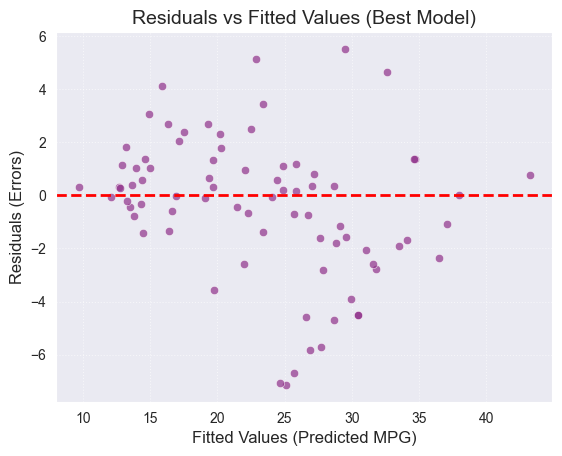

In [19]:
residual = y_test - ridge_predict
plt.Figure(figsize=(8,5))
sns.scatterplot(x=ridge_predict , y=residual , alpha = 0.7 , color ="#8f318a")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
#plt.title("Residual Plot")
#plt.show()
plt.title("Residuals vs Fitted Values (Best Model)", fontsize=14)
plt.xlabel("Fitted Values (Predicted MPG)", fontsize=12)
plt.ylabel("Residuals (Errors)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

<table style="width: 100%; max-width: 800px; border-left: 6px solid #5bc0de; background-color: #d9edf7; border-collapse: collapse; margin-bottom: 20px;">
    <tr>
        <td style="padding: 15px; font-family: sans-serif;">
            <p style="color: #333; font-size: 14px; line-height: 1.6; margin: 0 0 10px 0;">
                Based on the generated <b>Residuals vs Fitted Values</b> plot, we can extract the following key structural insights about our best model:
            </p>
            <ul style="color: #333; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
                <li style="margin-bottom: 10px;">
                    <b>Random Scatter Around Zero:</b> The residuals are generally well-distributed above and below the reference line (y = 0). There is no distinct curved or U-shaped pattern, which safely confirms that the <b>Polynomial Degree 2 feature expansion</b> successfully captured the core non-linear relationships within the dataset.
                </li>
                <li style="margin-bottom: 10px;">
                    <b>Slight Heteroscedasticity & Funnel Trend:</b> A subtle variance expansion is visible, particularly between 25 and 32 MPG where the errors stretch down toward -7. The model provides tighter, more stable predictions for low-to-moderate fuel-efficient vehicles but exhibits fluctuating residual variance as the predicted MPG values increase.
                </li>
                <li style="margin-bottom: 5px;">
                    <b>Data Skewness Impact:</b> This slight heteroscedasticity is directly tied to the <b>positively skewed distribution</b> and high-efficiency outliers identified during the initial EDA. Since extreme high-MPG data points are sparse, the model yields higher residual variance in that specific zone due to the lack of sufficient training examples.
                </li>
            </ul>
        </td>
    </tr>
</table>

<h2 style = "color:red"> 7-Insight & Conclusions </h2>

<div style="background-color: #f4f9f4; padding: 18px; border-left: 5px solid #2e7d32; margin-bottom: 15px; font-family: sans-serif;">
    <h4 style="color: #2e7d32; margin: 0 0 8px 0; font-size: 15px;">1. Key Data Revelations and Observations</h4>
    <ul style="color: #444; font-size: 14px; line-height: 1.6; padding-left: 20px; margin: 0;">
        <li style="margin-bottom: 6px;"><b>Non-Linear Reality:</b> The baseline Linear model left a massive chunk of variance unexplained (R² = 0.7902). Moving to a polynomial structure proved that vehicle fuel efficiency (MPG) does not scale linearly with engine displacement or weight.</li>
        <li style="margin-bottom: 6px;"><b>The Overfitting Cliff:</b> As the polynomial degree increased beyond 2, the error exploded catastrophically. Degree 5 reached an MSE of 100.0036 and a negative R², proving that higher dimensions capture pure noise.</li>
        <li><b>The Outlier Tail:</b> Across all models, RMSE stayed consistently higher than MAE. This statistical behavior highlights the lingering impact of the heavy right-skewed outliers present in the dataset.</li>
    </ul>
</div>

<div style="background-color: #f4f8fa; padding: 18px; border-left: 5px solid #31708f; margin-bottom: 15px; font-family: sans-serif;">
    <h4 style="color: #31708f; margin: 0 0 8px 0; font-size: 15px;">2. The Most Crucial Metric</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.6; margin: 0;">
        <b>RMSE and MAPE mattered most for this automotive problem:</b><br>
        • <b>MAPE (8.73%):</b> Essential because it translates the engineering errors into an intuitive percentage that stakeholders can easily judge.<br>
        • <b>RMSE (2.67):</b> Critical because fuel efficiency forecasting heavily penalizes large unexpected drops or spikes. It ensured our final model stays conservative and robust.
    </p>
</div>

<div style="background-color: #fcf9f2; padding: 18px; border-left: 5px solid #b78103; margin-bottom: 15px; font-family: sans-serif;">
    <h4 style="color: #b78103; margin: 0 0 8px 0; font-size: 15px;">3. Best Complexity Fit</h4>
    <p style="color: #444; font-size: 14px; line-height: 1.6; margin: 0;">
        <b>Polynomial Degree 2 combined with Ridge Regularization (Alpha = 0.01) performed best.</b><br>
        This reveals that the dataset's true complexity is moderately non-linear but highly sensitive to multicollinearity. A quadratic expansion captured the physical laws governing fuel consumption, while Ridge successfully suppressed the variance spikes caused by highly correlated features.
    </p>
</div>